In [1]:
# ==========================
# 🧠 EDA - Jena Climate Dataset
# ==========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị
plt.style.use('seaborn-v0_8')
sns.set_theme(color_codes=True)
plt.rcParams['figure.figsize'] = (12, 5)


In [4]:
import pandas as pd

df = pd.read_csv(r'C:\Users\QUANG TRUNG\Downloads\jena_climate_2009_2016.csv')
# Kiểm tra nhanh các giá trị nhỏ nhất để phát hiện bất thường
# print(df.describe().loc['min'])

# Các giá trị -9999.0 là lỗi đo lường.
# Một cách xử lý phổ biến là thay thế chúng bằng 0.0 (vì vận tốc gió không thể âm)
df['wv (m/s)'].replace(-9999.0, 0.0, inplace=True)
df['max. wv (m/s)'].replace(-9999.0, 0.0, inplace=True)

# Chuyển cột Date Time sang datetime đúng format
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')

# Đặt cột thời gian làm index
df = df.set_index('Date Time')


C:\Users\QUANG TRUNG\AppData\Local\Temp\ipykernel_15208\2273694027.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['wv (m/s)'].replace(-9999.0, 0.0, inplace=True)
C:\Users\QUANG TRUNG\AppData\Local\Temp\ipykernel_15208\2273694027.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

In [5]:
print("Số dòng dữ liệu:", len(df))
print("\nThống kê mô tả:")
display(df.describe())



Số dòng dữ liệu: 420551

Thống kê mô tả:


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000
mean,989.212776,9.450147,283.492743,4.955854,76.008259,13.576251,9.533756,4.042412,6.022408,9.640223,1216.062748,2.130191,3.532074,174.743738
std,8.358481,8.423365,8.504471,6.730674,16.476175,7.739020,4.184164,4.896851,2.656139,4.235395,39.975208,1.542334,2.340482,86.681693
min,913.600000,-23.010000,250.600000,-25.010000,12.950000,0.950000,0.790000,0.000000,0.500000,0.800000,1059.450000,0.000000,0.000000,0.000000
25%,984.200000,3.360000,277.430000,0.240000,65.210000,7.780000,6.210000,0.870000,3.920000,6.290000,1187.490000,0.990000,1.760000,124.900000
50%,989.580000,9.420000,283.470000,5.220000,79.300000,11.820000,8.860000,2.190000,5.590000,8.960000,1213.790000,1.760000,2.960000,198.100000
75%,994.720000,15.470000,289.530000,10.070000,89.400000,17.600000,12.350000,5.300000,7.800000,12.490000,1242.770000,2.860000,4.740000,234.100000
max,1015.350000,37.280000,311.340000,23.110000,100.000000,63.770000,28.320000,46.010000,18.130000,28.820000,1393.540000,28.490000,23.500000,360.000000


In [6]:
# Giảm nhiễu: lấy trung bình theo ngày
daily = df.resample('D').mean()
daily.head()


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01,999.145594,-6.810629,266.414545,-8.015594,91.086014,3.691119,3.355524,0.335315,2.091049,3.357832,1305.178252,0.778601,1.378252,181.863077
2009-01-02,999.600625,-3.728194,269.463194,-4.824861,92.086806,4.640069,4.267292,0.373056,2.659792,4.268750,1290.353194,1.419514,2.227361,125.072014
2009-01-03,998.548611,-5.271736,268.002292,-9.015833,76.458056,4.184792,3.107708,1.077014,1.937778,3.111944,1297.117014,1.250903,2.065069,190.383333
2009-01-04,988.510694,-1.375208,272.685347,-2.897014,89.417361,5.524306,4.938958,0.584861,3.114028,4.997014,1264.634514,1.720417,3.564861,213.069861
2009-01-05,990.405694,-4.867153,269.039306,-6.797292,86.260417,4.362708,3.806736,0.555625,2.397014,3.847778,1284.372778,3.800278,5.940000,118.287361


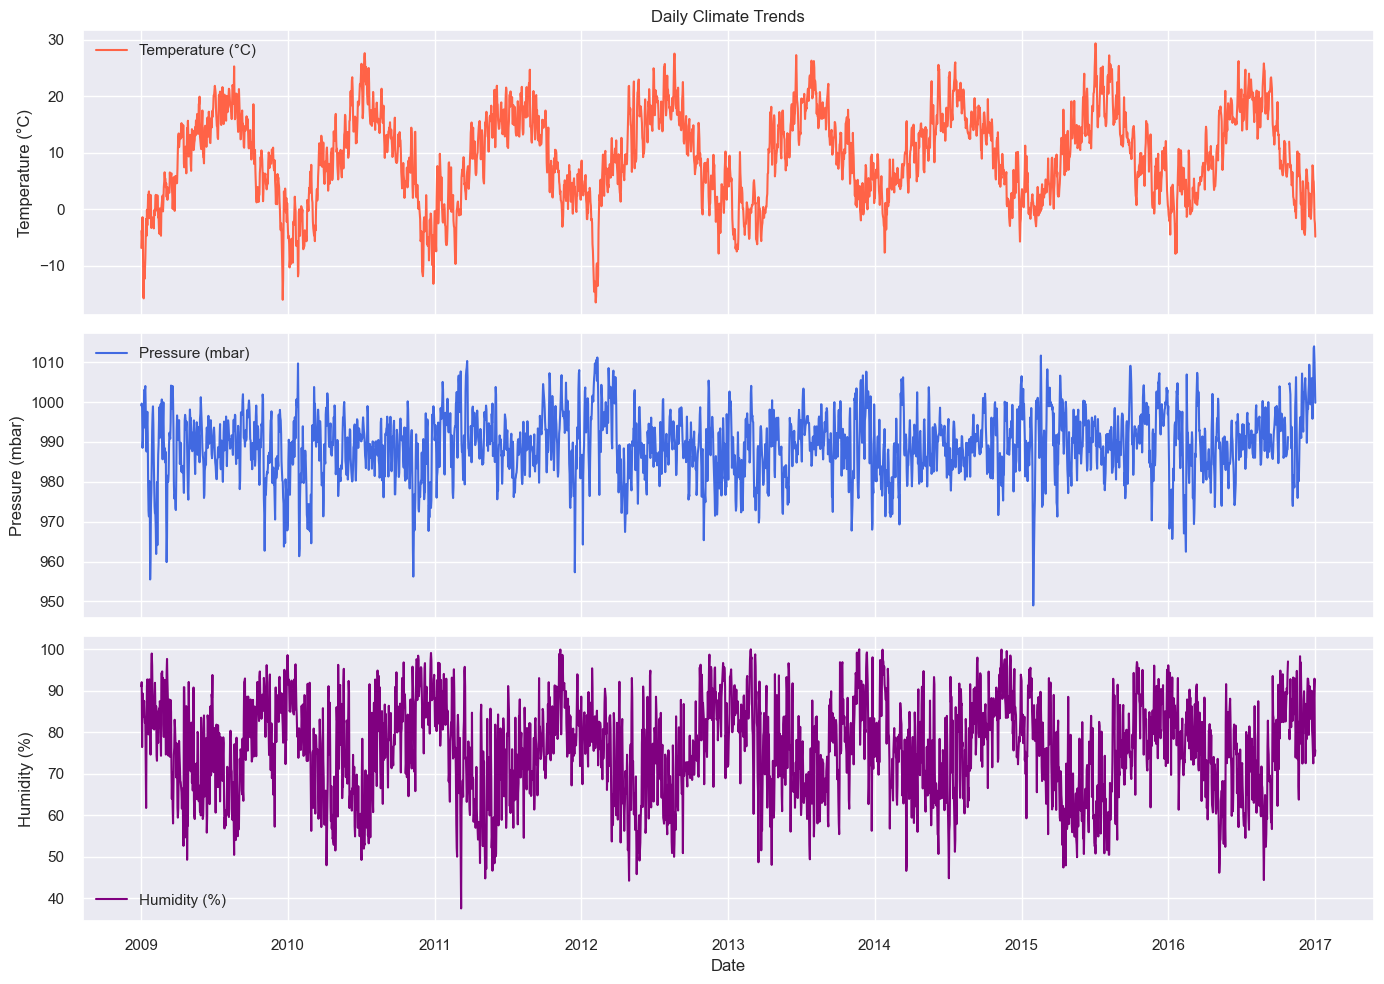

In [ ]:
# Tạo 3 biểu đồ con xếp chồng lên nhau, chia sẻ trục X
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 10), sharex=True)

# Biểu đồ 1: Nhiệt độ
axes[0].plot(daily.index, daily['T (degC)'], label='Temperature (°C)', color='tomato')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()
axes[0].set_title('Daily Climate Trends') # Chỉ cần title ở biểu đồ trên cùng

# Biểu đồ 2: Áp suất
axes[1].plot(daily.index, daily['p (mbar)'], label='Pressure (mbar)', color='royalblue')
axes[1].set_ylabel('Pressure (mbar)')
axes[1].legend()

# Biểu đồ 3: Độ ẩm
axes[2].plot(daily.index, daily['rh (%)'], label='Humidity (%)', color='purple')
axes[2].set_ylabel('Humidity (%)')
axes[2].legend()

# Đặt nhãn X cho biểu đồ cuối cùng
axes[2].set_xlabel('Date')

plt.tight_layout() 
plt.show()

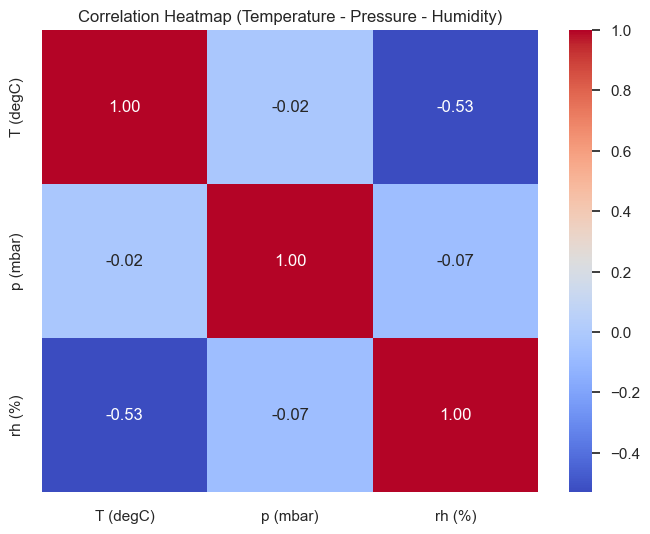

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
corr = daily[['T (degC)', 'p (mbar)', 'rh (%)']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Temperature - Pressure - Humidity)')
plt.show()


C:\Users\QUANG TRUNG\AppData\Local\Temp\ipykernel_1220\3818859033.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month', y='T (degC)', data=daily, palette='coolwarm')


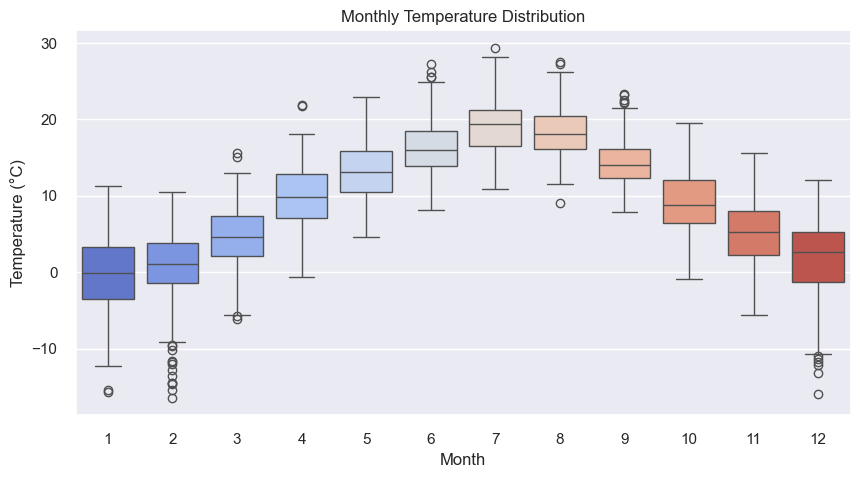

In [14]:
daily['month'] = daily.index.month
plt.figure(figsize=(10,5))
sns.boxplot(x='month', y='T (degC)', data=daily, palette='coolwarm')
plt.title('Monthly Temperature Distribution')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.show()


C:\Users\QUANG TRUNG\AppData\Local\Temp\ipykernel_1220\70714928.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = daily.resample('Y').mean()


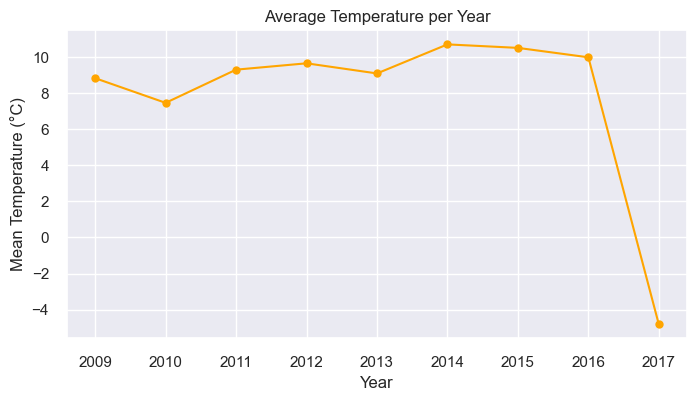

In [15]:
yearly = daily.resample('Y').mean()
plt.figure(figsize=(8,4))
plt.plot(yearly.index.year, yearly['T (degC)'], marker='o', color='orange')
plt.title('Average Temperature per Year')
plt.xlabel('Year')
plt.ylabel('Mean Temperature (°C)')
plt.grid(True)
plt.show()
